In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

In [5]:
data = pd.read_excel(r"C:\Users\rahul\OneDrive\Desktop\Main projects\1683267888_dataset (1)\Dataset\data.xlsx")

In [7]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
data.shape

(303, 14)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [17]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
data.describe(exclude = 'number')

In [23]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [25]:
data.duplicated().sum()

1

In [29]:
data = data.drop_duplicates()

In [33]:
data.duplicated().sum()

0

In [35]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [37]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

numerical_cols, categorical_cols

(Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
        'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
       dtype='object'),
 Index([], dtype='object'))

In [39]:
print("Preliminary Statistical Summary of the Dataset:\n")
print(data.describe())

Preliminary Statistical Summary of the Dataset:

             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351   

In [45]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

print("\nInterquartile Range (IQR) of Numerical Variables:\n")
print(IQR)


Interquartile Range (IQR) of Numerical Variables:

age         13.00
sex          1.00
cp           2.00
trestbps    20.00
chol        63.75
fbs          0.00
restecg      1.00
thalach     32.75
exang        1.00
oldpeak      1.60
slope        1.00
ca           1.00
thal         1.00
target       1.00
dtype: float64


In [47]:
data_range = data.max() - data.min()

print("\nRange (Max - Min) of Numerical Variables:\n")
print(data_range)


Range (Max - Min) of Numerical Variables:

age          48.0
sex           1.0
cp            3.0
trestbps    106.0
chol        438.0
fbs           1.0
restecg       2.0
thalach     131.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
target        1.0
dtype: float64


In [49]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 
                    'slope', 'ca', 'thal', 'target']

print("Categorical Variables in the Dataset:\n")
print(categorical_cols)

Categorical Variables in the Dataset:

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [51]:
for col in categorical_cols:
    print(f"\nValue counts for {col}:\n")
    print(data[col].value_counts())


Value counts for sex:

sex
1    206
0     96
Name: count, dtype: int64

Value counts for cp:

cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64

Value counts for fbs:

fbs
0    257
1     45
Name: count, dtype: int64

Value counts for restecg:

restecg
1    151
0    147
2      4
Name: count, dtype: int64

Value counts for exang:

exang
0    203
1     99
Name: count, dtype: int64

Value counts for slope:

slope
2    141
1    140
0     21
Name: count, dtype: int64

Value counts for ca:

ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

Value counts for thal:

thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64

Value counts for target:

target
1    164
0    138
Name: count, dtype: int64


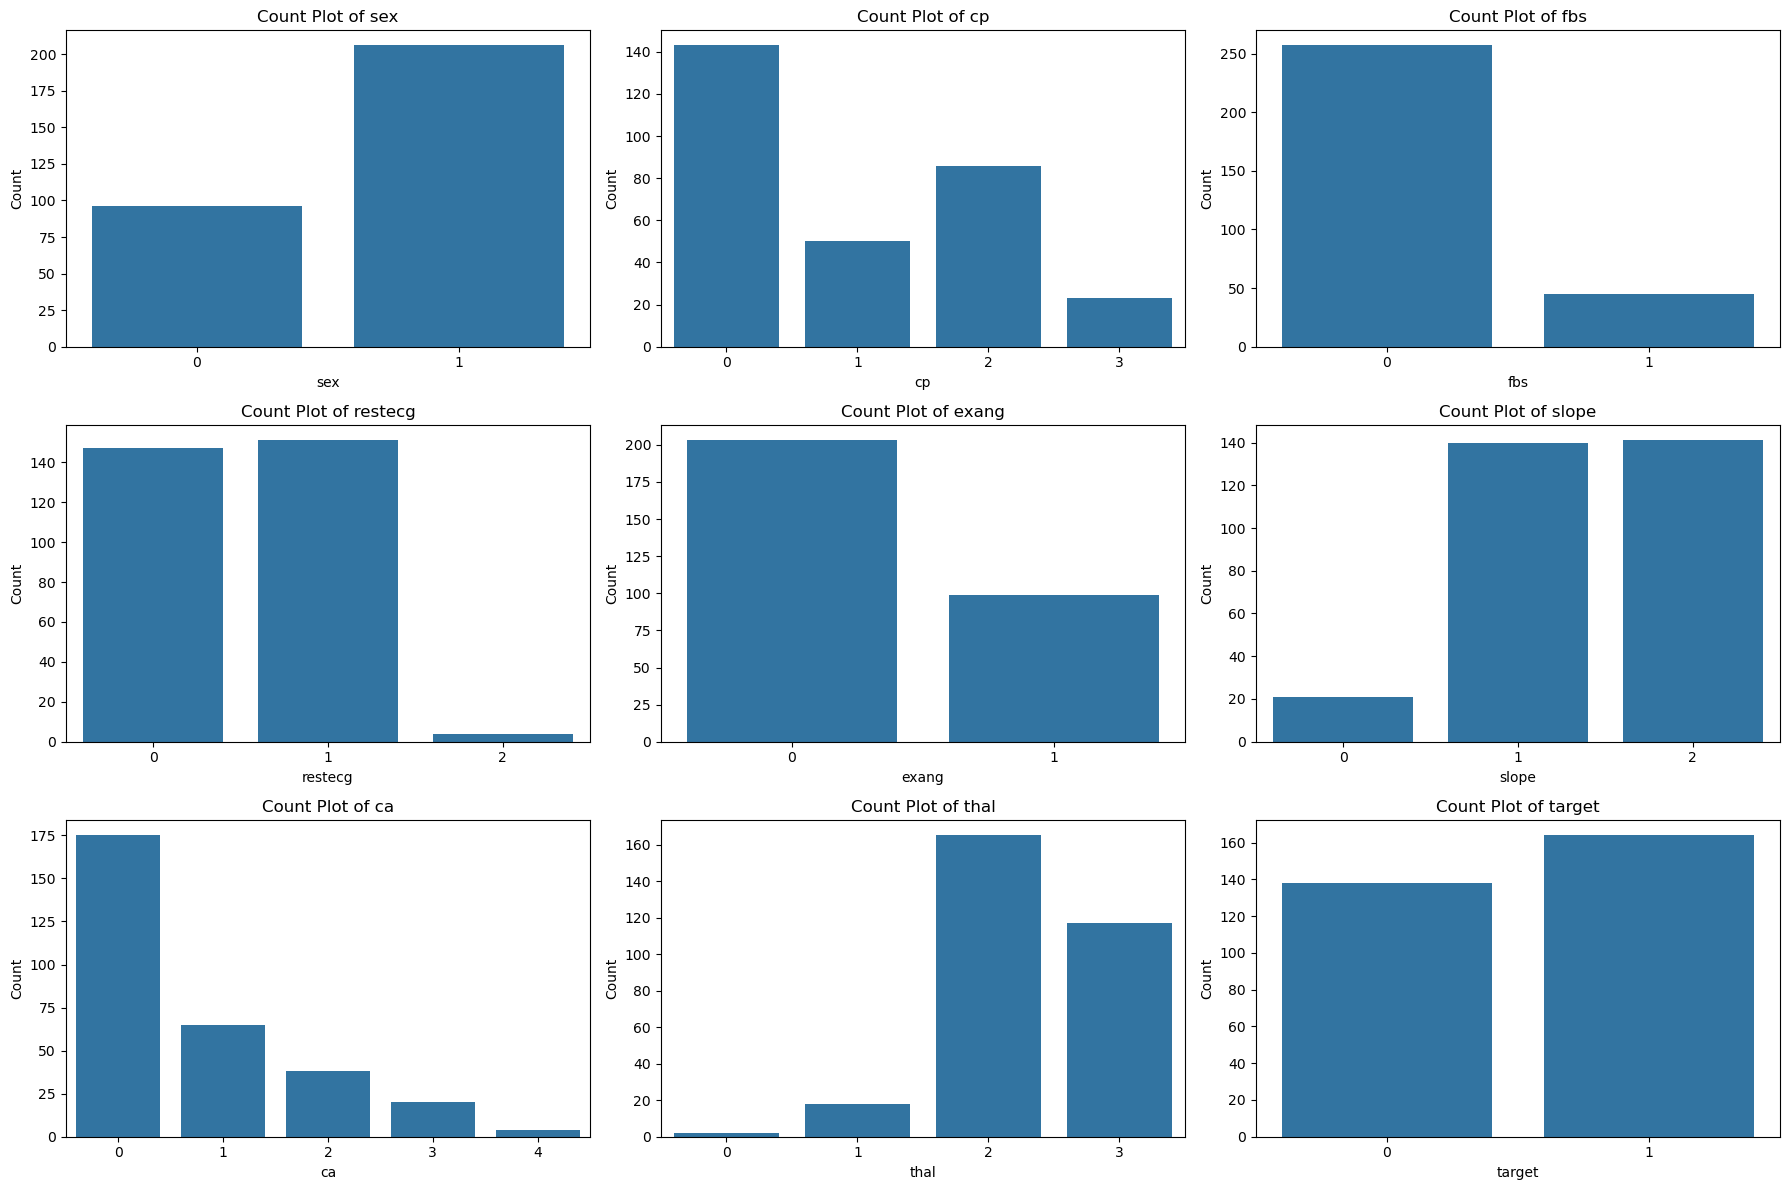

In [54]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=data)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [56]:
print("Occurrence of Cardiovascular Disease (CVD) across different ages:\n")

age_cvd = data.groupby('age')['target'].mean()
print(age_cvd)

Occurrence of Cardiovascular Disease (CVD) across different ages:

age
29    1.000000
34    1.000000
35    0.500000
37    1.000000
38    0.500000
39    0.750000
40    0.333333
41    0.900000
42    0.875000
43    0.625000
44    0.727273
45    0.750000
46    0.571429
47    0.600000
48    0.571429
49    0.600000
50    0.571429
51    0.750000
52    0.692308
53    0.750000
54    0.625000
55    0.375000
56    0.454545
57    0.411765
58    0.368421
59    0.357143
60    0.272727
61    0.125000
62    0.363636
63    0.333333
64    0.600000
65    0.500000
66    0.571429
67    0.333333
68    0.500000
69    0.666667
70    0.250000
71    1.000000
74    1.000000
76    1.000000
77    0.000000
Name: target, dtype: float64


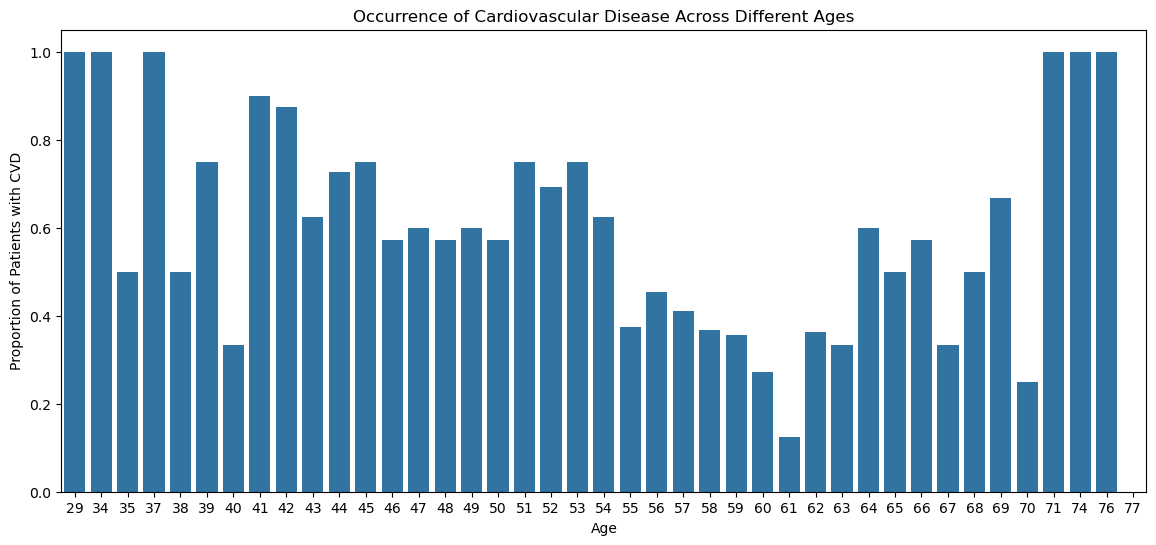

In [60]:
plt.figure(figsize=(14, 6))
sns.barplot(x=age_cvd.index, y=age_cvd.values)
plt.title("Occurrence of Cardiovascular Disease Across Different Ages")
plt.xlabel("Age")
plt.ylabel("Proportion of Patients with CVD")
plt.show()

In [62]:
print("Resting Blood Pressure Statistics by CVD Status:\n")

bp_summary = data.groupby('target')['trestbps'].describe()
print(bp_summary)

Resting Blood Pressure Statistics by CVD Status:

        count        mean        std    min    25%    50%     75%    max
target                                                                  
0       138.0  134.398551  18.729944  100.0  120.0  130.0  144.75  200.0
1       164.0  129.250000  16.204739   94.0  120.0  130.0  140.00  180.0


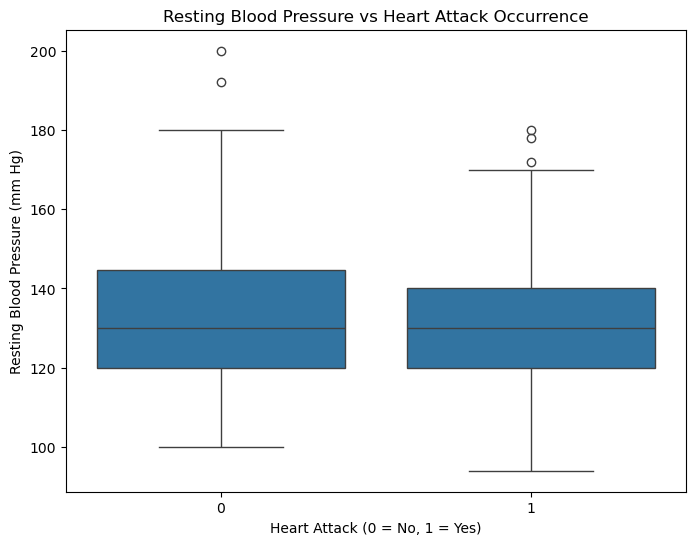

In [64]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='trestbps', data=data)
plt.title("Resting Blood Pressure vs Heart Attack Occurrence")
plt.xlabel("Heart Attack (0 = No, 1 = Yes)")
plt.ylabel("Resting Blood Pressure (mm Hg)")
plt.show()

In [66]:
print("Gender composition of patients:\n")

gender_counts = data['sex'].value_counts()
print(gender_counts)

Gender composition of patients:

sex
1    206
0     96
Name: count, dtype: int64


In [68]:
print("\nGender composition in percentage:\n")

gender_percent = data['sex'].value_counts(normalize=True) * 100
print(gender_percent)


Gender composition in percentage:

sex
1    68.211921
0    31.788079
Name: proportion, dtype: float64


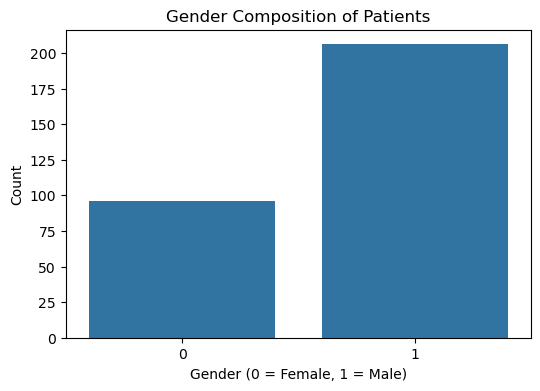

In [70]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=data)
plt.title("Gender Composition of Patients")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

In [72]:
print("Cholesterol level statistics by heart disease status:\n")

chol_summary = data.groupby('target')['chol'].describe()
print(chol_summary)

Cholesterol level statistics by heart disease status:

        count        mean        std    min     25%    50%     75%    max
target                                                                   
0       138.0  251.086957  49.454614  131.0  217.25  249.0  283.00  409.0
1       164.0  242.640244  53.456580  126.0  208.75  234.5  267.25  564.0


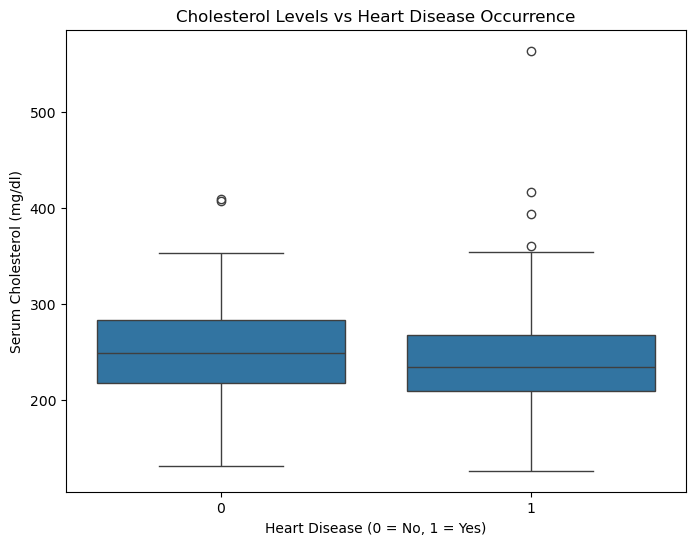

In [74]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='chol', data=data)
plt.title("Cholesterol Levels vs Heart Disease Occurrence")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Serum Cholesterol (mg/dl)")
plt.show()

In [76]:
print("Peak exercise (maximum heart rate) statistics by heart attack status:\n")

thalach_summary = data.groupby('target')['thalach'].describe()
print(thalach_summary)

Peak exercise (maximum heart rate) statistics by heart attack status:

        count        mean        std   min     25%    50%    75%    max
target                                                                 
0       138.0  139.101449  22.598782  71.0  125.00  142.0  156.0  195.0
1       164.0  158.378049  19.199080  96.0  148.75  161.0  172.0  202.0


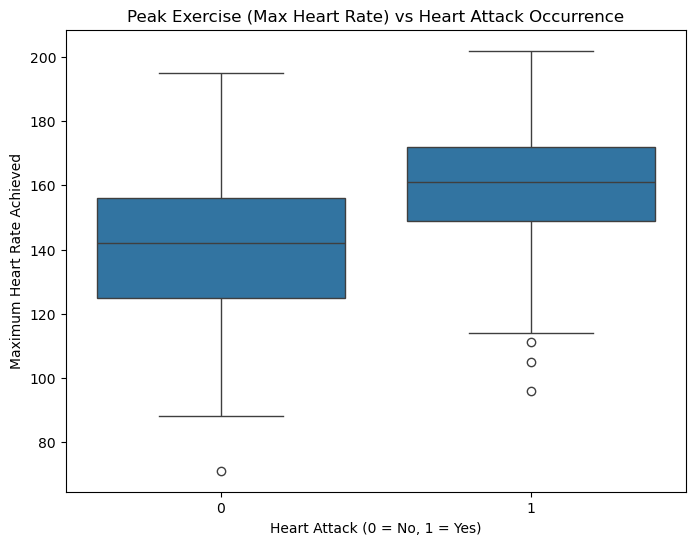

In [78]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='thalach', data=data)
plt.title("Peak Exercise (Max Heart Rate) vs Heart Attack Occurrence")
plt.xlabel("Heart Attack (0 = No, 1 = Yes)")
plt.ylabel("Maximum Heart Rate Achieved")
plt.show()

In [80]:
print("Thalassemia vs Heart Disease (frequency table):\n")

thal_cvd = pd.crosstab(data['thal'], data['target'])
print(thal_cvd)

Thalassemia vs Heart Disease (frequency table):

target   0    1
thal           
0        1    1
1       12    6
2       36  129
3       89   28


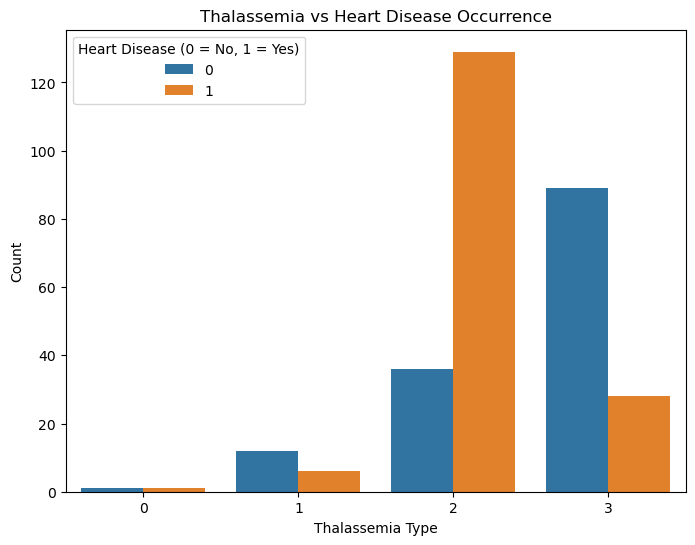

In [82]:
plt.figure(figsize=(8, 6))
sns.countplot(x='thal', hue='target', data=data)
plt.title("Thalassemia vs Heart Disease Occurrence")
plt.xlabel("Thalassemia Type")
plt.ylabel("Count")
plt.legend(title="Heart Disease (0 = No, 1 = Yes)")
plt.show()

In [84]:
print("Comparison of key clinical factors by CVD status:\n")

key_factors = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

factor_summary = data.groupby('target')[key_factors].mean()
print(factor_summary)

Comparison of key clinical factors by CVD status:

              age        chol    trestbps     thalach   oldpeak
target                                                         
0       56.601449  251.086957  134.398551  139.101449  1.585507
1       52.585366  242.640244  129.250000  158.378049  0.586585


Generating pair plot to study relationships between variables...



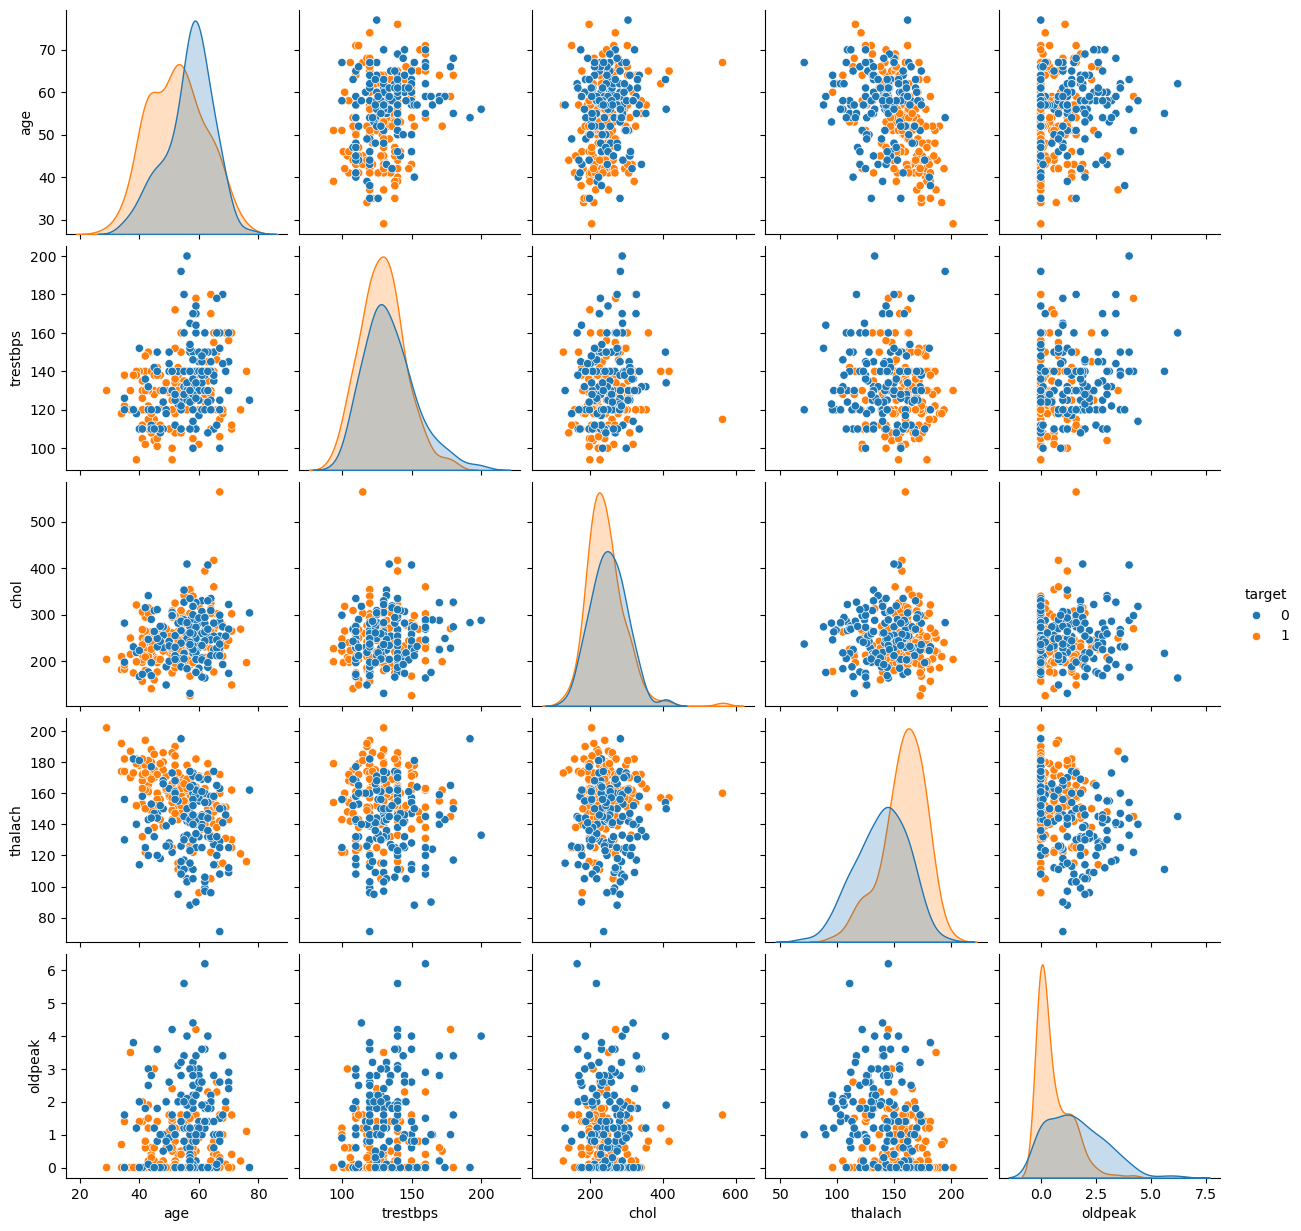

In [92]:

print("Generating pair plot to study relationships between variables...\n")

selected_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

sns.pairplot(data[selected_cols], hue='target' ,diag_kind='kde')
plt.show()

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [96]:
X = data.drop('target', axis=1)
y = data['target']

print("Shape of feature matrix:", X.shape)
print("Shape of target vector:", y.shape)

Shape of feature matrix: (302, 13)
Shape of target vector: (302,)


In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (241, 13)
Testing data size: (61, 13)


In [102]:
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [104]:
y_pred = log_reg.predict(X_test)

print("Predicted values for test data:\n")
print(y_pred)

Predicted values for test data:

[0 0 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 1 0 1 0 1
 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 1]


In [106]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[24  5]
 [ 6 26]]


In [108]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

